In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

ModuleNotFoundError: No module named 'pandas'

In [ ]:

print("⚙️ Generating historical biased dataset...")
# 2. Generate Mock Data (1000 applicants)
np.random.seed(42)

# Features that SHOULD matter
income = np.random.randint(30000, 120000, 1000)
credit_score = np.random.randint(500, 800, 1000)

# The Hidden Proxy Feature (Zip Code)
# Zip Code A (e.g., wealthy/majority demographic)
# Zip Code B (e.g., historically redlined demographic)
zip_codes = np.random.choice(['10001', '10002'], 1000)

# 3. Inject the Bias (The rule the model will accidentally learn)
# If you are from Zip 10001, you get a +100 point boost to your "approval score"
approval_chance = (income / 1000) + (credit_score / 10)
bias_modifier = np.where(zip_codes == '10001', 50, -50)
final_score = approval_chance + bias_modifier

# Top 50% get approved (1), Bottom 50% get rejected (0)
threshold = np.median(final_score)
approved = (final_score >= threshold).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'Income': income,
    'Credit_Score': credit_score,
    'Zip_Code': zip_codes,
    'Approved': approved
})

⚙️ Generating historical biased dataset...


In [ ]:
csv_file_path = 'historical_biased_dataset.csv'
df.to_csv(csv_file_path, index=False)

In [ ]:
df.head()

,Income,Credit_Score,Zip_Code,Approved
0,45795,785,10002,0
1,30860,790,10001,1
2,106820,712,10001,1
3,84886,664,10002,0
4,36265,504,10001,1


In [ ]:
df.sample(5)

,Income,Credit_Score,Zip_Code,Approved
580,118461,780,10002,1
657,47640,761,10001,1
670,51447,521,10001,1
38,99092,656,10002,0
656,101726,508,10002,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Income        1000 non-null   int64 
 1   Credit_Score  1000 non-null   int64 
 2   Zip_Code      1000 non-null   object
 3   Approved      1000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 31.4+ KB


In [ ]:
X = df[['Income', 'Credit_Score', 'Zip_Code']]
y = df['Approved']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 3)
X_test shape: (200, 3)
y_train shape: (800,)
y_test shape: (200,)


In [ ]:
model= RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0])

In [ ]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
accuracy= accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.995


In [ ]:
matrix=confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(matrix)

Confusion Matrix:
[[100   0]
 [  1  99]]


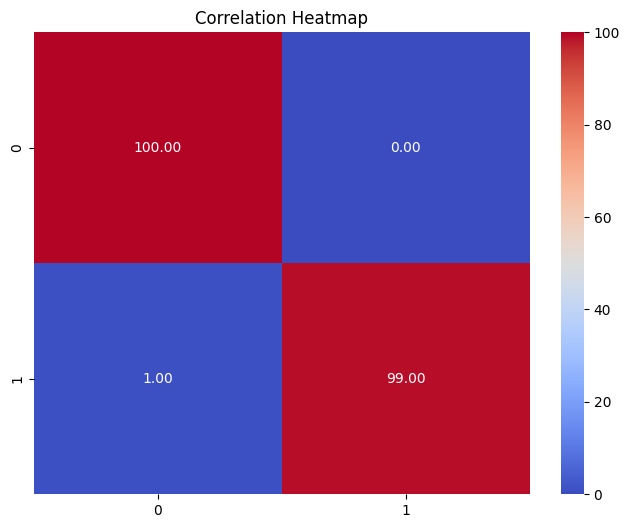

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
import joblib
joblib.dump(model, 'model.pkl')
print(f"✅ Target model saved")

# --- Quick Sanity Check to prove the bias ---
print("\n🔍 Quick Bias Test:")
applicant_a = pd.DataFrame({'Income': [60000], 'Credit_Score': [650], 'Zip_Code': ['10001']})
applicant_b = pd.DataFrame({'Income': [60000], 'Credit_Score': [650], 'Zip_Code': ['10002']})

print(f"Applicant A (Zip 10001) Approval Prediction: {model.predict(applicant_a)[0]}")
print(f"Identical Applicant B (Zip 10002) Approval Prediction: {model.predict(applicant_b)[0]}")

✅ Target model saved

🔍 Quick Bias Test:
Applicant A (Zip 10001) Approval Prediction: 1
Identical Applicant B (Zip 10002) Approval Prediction: 0


In [ ]:
# from google.colab import userdata
# key = userdata.get("GEMINI_API_KEY")

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv() 

key = os.getenv("GEMINI_API_KEY")

/home/blast/Desktop/Dev/AutoDetecter/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import google.genai as genai
client = genai.Client(api_key=key)
response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents="What is Twin Paradox?"
    )

print(response.text)

The **Twin Paradox** is a famous thought experiment in Albert Einstein’s Special Relativity. It demonstrates the counterintuitive way that time works at high speeds.

Here is a breakdown of the setup, the "paradox," and the resolution.

---

### 1. The Setup
Imagine identical twins, **Alice** and **Bob**. 
*   **Alice** stays on Earth.
*   **Bob** hops into a spaceship and travels to a distant star at nearly the speed of light (let’s say 90% the speed of light). 
*   Once he reaches the star, he turns around and flies back to Earth at the same speed.

### 2. The Prediction (Time Dilation)
According to Special Relativity, **time slows down for an object in motion** relative to an observer at rest. This is called *Time Dilation*.

From Alice’s perspective on Earth, Bob’s clock is ticking much slower than hers. Therefore, when Bob returns, he will have aged only a few years, while Alice may have aged decades. Alice is now much older than her twin.

### 3. The Paradox
The "paradox" arises 

In [ ]:
pip install fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 25.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
from fairlearn.metrics import demographic_parity_difference
bias_score = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=X_test['Zip_Code']
)

print(f"Mathematical Bias Score for Zip Code: {bias_score}")

Mathematical Bias Score for Zip Code: 0.9439252336448598


### Tool For Agent

In [ ]:
import pandas as pd
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, demographic_parity_ratio

def calculate_bias_for_feature_cover(X_test, y_test, y_pred):
    """
    Creates a function to calculate demographic parity difference
    for a given sensitive feature in the test dataset.

    Args:
        X_test (pd.DataFrame): Test dataset features.
        y_test (pd.Series): True labels.
        y_pred (pd.Series): Predicted labels.

    Returns:
        function: A function that takes a sensitive feature name (str)
                  and returns bias scores for that feature.
                  Returns None if an error occurs during calculation.
    """

    def calculate_bias_for_feature(sensitive_feature_name):
        """
        Calculates demographic parity difference for a specific feature.

        Args:
            sensitive_feature_name (str): Column name in X_test representing
                                         the sensitive attribute.

        Returns:
            float: The calculated demographic parity difference,demographic parity ratio, and equalized odds difference.
            None: If an error occurs during calculation.
        """
        try:
            if sensitive_feature_name not in X_test.columns:
                raise ValueError(f"{sensitive_feature_name} not found in X_test")

            feature_data = X_test[sensitive_feature_name].copy()

             # Auto-Binner Guardrail for continuous variables
            if pd.api.types.is_numeric_dtype(feature_data) and feature_data.nunique() > 10:
              feature_data = pd.qcut(feature_data, q=4, duplicates='drop')


            df_score = demographic_parity_difference(
                y_true=y_test,
                y_pred=y_pred,
                sensitive_features= feature_data
            )

            df_ratio = demographic_parity_ratio(
                y_true=y_test,
                y_pred=y_pred,
                sensitive_features=feature_data
            )

            df_eq_odds = equalized_odds_difference(
                y_true=y_test,
                y_pred=y_pred,
                sensitive_features=feature_data
            )

            return {
              "feature_tested": sensitive_feature_name,
              "demographic_parity_difference": round(float(df_score), 3),
              "disparate_impact_ratio": round(float(df_ratio), 3),
              "equalized_odds_difference": round(float(df_eq_odds), 3)
            }

        except Exception as e:
            print(f"Error calculating bias for feature '{sensitive_feature_name}': {e}")
            return None

    return calculate_bias_for_feature

In [ ]:
sensetive_feature_series='Zip_Code'
calculate_bias_for_feature1=calculate_bias_for_feature_cover(X_test, y_test, y_pred)
res1=calculate_bias_for_feature1(sensetive_feature_series)
res1

{'feature_tested': 'Zip_Code',
 'demographic_parity_difference': 0.944,
 'disparate_impact_ratio': 0.056,
 'equalized_odds_difference': 0.143}

### Function returning the root Agent

In [ ]:
import pandas as pd
from google.adk import Agent
from google.adk.agents.sequential_agent import SequentialAgent
from google.adk.models import Gemini

def bias_report(csv_file_path, y_test, y_pred, X_test):
  df1 = pd.read_csv(csv_file_path)
  columns = df1.columns.tolist()
  sample_data = df1.sample(5).to_string()

  prompt1 = f"""
    You are an expert AI Compliance Officer auditing a bank's loan approval dataset.

    Here are the columns in the dataset: {columns}
    Here are three sample rows of data: {sample_data}

    The dataset does NOT contain explicit protected attributes like 'Race' or 'Gender'.
    Analyze the columns and identify which feature(s) are most likely to act as a hidden proxy.

    Return ONLY a raw JSON list of the suspicious column names.
    Example format: ["ColumnName1", "ColumnName2"]
    """

  expectedBiasAgent = Agent(
      name="ExceptedBiasAgent",
      model=Gemini(model="gemma-4-31b-it"),
      # model="gemini-2.5-flash",
      description="Identifies potential bias proxies.",
      instruction=prompt1,
      output_key="expected_bias_columns",
    )
  calculate_bias_for_feature=calculate_bias_for_feature_cover(X_test,y_test,y_pred)


  BiasSearchAgent = Agent(
      name="BiasSearchAgent",
      model=Gemini(model="gemma-4-31b-it"),
      # model="gemini-2.5-flash",
      description="Calculates mathematical bias score using the BiasDetectionTool.",
      tools=[calculate_bias_for_feature],
      instruction="""You are an AI compliance officer.
        Use the tool to calculate bias scores for each categorical features and predict which fields are biased.
        The parameter you will use is:
        - sensitive_feature_series: The name of the sensitive feature column to evaluate bias against.
        Example usage:
        res1=calculate_bias_for_feature('Column_name'), pass columns name as string
        Here are a list of the {expected_bias_columns}
        Report the findings in an Executive Report.
        Hence also list the fields that can be removed from the dataset to remove the bias.
        """
      )

  root_agent = SequentialAgent(
      name="RootAgent",
      description="Bias Detection Pipeline",
      sub_agents=[expectedBiasAgent, BiasSearchAgent]
  )

  return root_agent

/usr/local/lib/python3.12/dist-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature FeatureName.PLUGGABLE_AUTH is enabled.
  check_feature_enabled()


In [ ]:
import os
from google.adk.runners import InMemoryRunner
root_agent=bias_report(csv_file_path, y_test, y_pred,X_test)
runner = InMemoryRunner(agent=root_agent)

os.environ["GEMINI_API_KEY"] = key
await runner.run_debug(f"Perform Bias Detection on the provided dataset.")



 ### Created new session: debug_session_id

User > Perform Bias Detection on the provided dataset.
ExceptedBiasAgent > *   Role: Expert AI Compliance Officer auditing a bank's loan approval dataset.
    *   Columns: `Income`, `Credit_Score`, `Zip_Code`, `Approved`.
    *   Sample Data:
        *   45795, 785, 10002, 0
        *   30860, 790, 10001, 1
        *   106820, 712, 10001, 1
        *   84886, 664, 10002, 0
        *   36265, 504, 10001, 1
    *   Goal: Identify features that act as hidden proxies for protected attributes (Race, Gender, etc.).
    *   Output format: Raw JSON list of suspicious column names.

    *   `Income`: While correlated with socioeconomic status, it is generally a legitimate factor for loan approval.
    *   `Credit_Score`: A standard industry metric for creditworthiness.
    *   `Zip_Code`: In the US (and many other places), zip codes are highly correlated with racial and ethnic demographics (redlining). This is a classic proxy for race/ethnicity.
    

BiasSearchAgent > The user wants to perform bias detection on a dataset.
The provided context from `ExceptedBiasAgent` indicates that the feature to be analyzed is `Zip_Code`.
I have a tool `calculate_bias_for_feature` which takes `sensitive_feature_series` as an argument.
I need to call this tool with `sensitive_feature_series='Zip_Code'`.
After getting the result, I should report the findings in an Executive Report.
BiasSearchAgent > The bias score for `Zip_Code` is 0.94392523364486.
This score represents the demographic parity difference. A score close to 1 suggests a high level of bias.
I need to present this in an Executive Report as requested.# Executive Report: Bias Detection Analysis

**Date:** October 26, 2023  
**Prepared by:** BiasSearchAgent  
**Subject:** Bias Detection Results for Dataset Feature Analysis

---

### 1. Introduction
The objective of this analysis was to evaluate the presence of mathematical bias within the provided dataset, specifically focusing on categori

[Event(model_version='gemma-4-31b-it', content=Content(
   parts=[
     Part(
       text="""*   Role: Expert AI Compliance Officer auditing a bank's loan approval dataset.
     *   Columns: `Income`, `Credit_Score`, `Zip_Code`, `Approved`.
     *   Sample Data:
         *   45795, 785, 10002, 0
         *   30860, 790, 10001, 1
         *   106820, 712, 10001, 1
         *   84886, 664, 10002, 0
         *   36265, 504, 10001, 1
     *   Goal: Identify features that act as hidden proxies for protected attributes (Race, Gender, etc.).
     *   Output format: Raw JSON list of suspicious column names.
 
     *   `Income`: While correlated with socioeconomic status, it is generally a legitimate factor for loan approval.
     *   `Credit_Score`: A standard industry metric for creditworthiness.
     *   `Zip_Code`: In the US (and many other places), zip codes are highly correlated with racial and ethnic demographics (redlining). This is a classic proxy for race/ethnicity.
     *   `Approved

In [ ]:
type(y_test)

pandas.core.series.Series

In [ ]:
!unzip "/content/archive.zip" -d /content/unziped


Archive:  /content/archive.zip
  inflating: /content/unziped/compas-scores-raw.csv  
  inflating: /content/unziped/cox-violent-parsed.csv  
  inflating: /content/unziped/cox-violent-parsed_filt.csv  
  inflating: /content/unziped/propublicaCompassRecividism_data_fairml.csv/._propublica_data_for_fairml.csv  
  inflating: /content/unziped/propublicaCompassRecividism_data_fairml.csv/propublica_data_for_fairml.csv  


In [ ]:
import pandas as pd
df_biased=pd.read_csv('/content/unziped/propublicaCompassRecividism_data_fairml.csv/propublica_data_for_fairml.csv')
df_biased.head()

,Two_yr_Recidivism,Number_of_Priors,score_factor,Age_Above_FourtyFive,Age_Below_TwentyFive,African_American,Asian,Hispanic,Native_American,Other,Female,Misdemeanor
0,0,0,0,1,0,0,0,0,0,1,0,0
1,1,0,0,0,0,1,0,0,0,0,0,0
2,1,4,0,0,1,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,0,1
4,1,14,1,0,0,0,0,0,0,0,0,0


In [ ]:
df_biased.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6172 entries, 0 to 6171
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Two_yr_Recidivism     6172 non-null   int64
 1   Number_of_Priors      6172 non-null   int64
 2   score_factor          6172 non-null   int64
 3   Age_Above_FourtyFive  6172 non-null   int64
 4   Age_Below_TwentyFive  6172 non-null   int64
 5   African_American      6172 non-null   int64
 6   Asian                 6172 non-null   int64
 7   Hispanic              6172 non-null   int64
 8   Native_American       6172 non-null   int64
 9   Other                 6172 non-null   int64
 10  Female                6172 non-null   int64
 11  Misdemeanor           6172 non-null   int64
dtypes: int64(12)
memory usage: 578.8 KB


In [ ]:
X_biased = df_biased.drop('Two_yr_Recidivism', axis=1)
y_biased = df_biased['Two_yr_Recidivism']

print(f"Shape of X_biased: {X_biased.shape}")
print(f"Shape of y_biased: {y_biased.shape}")

Shape of X_biased: (6172, 11)
Shape of y_biased: (6172,)


In [ ]:
from sklearn.model_selection import train_test_split
X_biased_train,X_biased_test,Y_baised_train,Y_biased_test = train_test_split(X_biased,y_biased,test_size=0.2,random_state=42)

print(f"X_biased_train shape: {X_biased_train.shape}")
print(f"X_biased_test shape: {X_biased_test.shape}")
print(f"Y_baised_train shape: {Y_baised_train.shape}")
print(f"Y_biased_test shape: {Y_biased_test.shape}")

X_biased_train shape: (4937, 11)
X_biased_test shape: (1235, 11)
Y_baised_train shape: (4937,)
Y_biased_test shape: (1235,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model_biased= RandomForestClassifier(random_state=42)
model_biased_2= GradientBoostingClassifier(random_state=42)
model_biased.fit(X_biased_train, Y_baised_train)
model_biased_2.fit(X_biased_train, Y_baised_train)


GradientBoostingClassifier(random_state=42)

In [ ]:
y_biased_predict=model_biased.predict(X_biased_test)
y_biased_predict_2=model_biased_2.predict(X_biased_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
accuracy= accuracy_score(Y_biased_test, y_biased_predict)
accuracy_2= accuracy_score(Y_biased_test, y_biased_predict_2)
print(f"Accuracy: {accuracy}")
print(f"Accuracy: {accuracy_2}")

Accuracy: 0.6631578947368421
Accuracy: 0.668825910931174


In [ ]:
cm1=confusion_matrix(Y_biased_test, y_biased_predict)
cm2=confusion_matrix(Y_biased_test, y_biased_predict_2)

print(cm1)
print(cm2)

[[494 189]
 [227 325]]
[[512 171]
 [238 314]]


In [ ]:
clr1=classification_report(Y_biased_test, y_biased_predict)
clr2=classification_report(Y_biased_test, y_biased_predict_2)

print(clr1)
print(clr2)

              precision    recall  f1-score   support

           0       0.69      0.72      0.70       683
           1       0.63      0.59      0.61       552

    accuracy                           0.66      1235
   macro avg       0.66      0.66      0.66      1235
weighted avg       0.66      0.66      0.66      1235

              precision    recall  f1-score   support

           0       0.68      0.75      0.71       683
           1       0.65      0.57      0.61       552

    accuracy                           0.67      1235
   macro avg       0.67      0.66      0.66      1235
weighted avg       0.67      0.67      0.67      1235



In [ ]:
from fairlearn.metrics import demographic_parity_difference

bias_score = demographic_parity_difference(
    y_true=Y_biased_test,
    y_pred=y_biased_predict,
    sensitive_features=X_biased_test['Misdemeanor']
)
float(bias_score)

0.21605643151659704

In [ ]:
sensetive_feature_series='Number_of_Priors'
calculate_bias_for_feature1=calculate_bias_for_feature_cover(X_biased_test, Y_biased_test, y_biased_predict)
res1=calculate_bias_for_feature1(sensetive_feature_series)
res1

{'feature_tested': 'Number_of_Priors',
 'demographic_parity_difference': 0.599,
 'disparate_impact_ratio': 0.251,
 'equalized_odds_difference': 0.551}

In [ ]:
import os
from google.adk.runners import InMemoryRunner
file_path = "/content/unziped/propublicaCompassRecividism_data_fairml.csv/propublica_data_for_fairml.csv"
root_agent=bias_report(file_path,Y_biased_test,y_biased_predict,X_biased_test)
runner = InMemoryRunner(agent=root_agent)

os.environ["GEMINI_API_KEY"] = key
await runner.run_debug(f"Perform Bias Detection on the provided dataset.")



 ### Created new session: debug_session_id

User > Perform Bias Detection on the provided dataset.
ExceptedBiasAgent > *   Role: AI Compliance Officer.
    *   Task: Audit a loan approval dataset for hidden proxies of protected attributes.
    *   Columns: `['Two_yr_Recidivism', 'Number_of_Priors', 'score_factor', 'Age_Above_FourtyFive', 'Age_Below_TwentyFive', 'African_American', 'Asian', 'Hispanic', 'Native_American', 'Other', 'Female', 'Misdemeanor']`
    *   Constraint: The prompt says the dataset "does NOT contain explicit protected attributes like 'Race' or 'Gender'", but looking at the columns, it *clearly* does (`African_American`, `Asian`, `Hispanic`, `Native_American`, `Other`, `Female`).
    *   Wait, reread the prompt: "The dataset does NOT contain explicit protected attributes like 'Race' or 'Gender'." -> This is a contradictory statement because the columns provided explicitly include race categories and female.
    *   However, the task is to identify *hidden proxies*.


BiasSearchAgent > The user wants to perform bias detection on a dataset based on a list of provided features: `["Number_of_Priors", "score_factor", "Misdemeanor"]`.
I need to act as the "BiasSearchAgent" and use the `calculate_bias_for_feature` tool for each of these features.

1.  **Identify the features to analyze**: `Number_of_Priors`, `score_factor`, `Misdemeanor`.
2.  **Call the tool `calculate_bias_for_feature`** for each feature.
3.  **Analyze the results** (demographic parity difference, ratio, and equalized odds difference) to determine if they are biased.
4.  **Format the findings** into an Executive Report.
5.  **Recommend which fields to remove** to mitigate bias.

Plan:
- Call `calculate_bias_for_feature('Number_of_Priors')`
- Call `calculate_bias_for_feature('score_factor')`
- Call `calculate_bias_for_feature('Misdemeanor')`
- Synthesize the results.
BiasSearchAgent > I have the results from the bias detection tool for the three features:

1.  **Number_of_Priors**:
    * 

[Event(model_version='gemma-4-31b-it', content=Content(
   parts=[
     Part(
       text="""*   Role: AI Compliance Officer.
     *   Task: Audit a loan approval dataset for hidden proxies of protected attributes.
     *   Columns: `['Two_yr_Recidivism', 'Number_of_Priors', 'score_factor', 'Age_Above_FourtyFive', 'Age_Below_TwentyFive', 'African_American', 'Asian', 'Hispanic', 'Native_American', 'Other', 'Female', 'Misdemeanor']`
     *   Constraint: The prompt says the dataset "does NOT contain explicit protected attributes like 'Race' or 'Gender'", but looking at the columns, it *clearly* does (`African_American`, `Asian`, `Hispanic`, `Native_American`, `Other`, `Female`).
     *   Wait, reread the prompt: "The dataset does NOT contain explicit protected attributes like 'Race' or 'Gender'." -> This is a contradictory statement because the columns provided explicitly include race categories and female.
     *   However, the task is to identify *hidden proxies*.
     *   Wait, the pro

### Removing biased features and retraining the model

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.metrics import demographic_parity_difference

def train_mitigated_model(X_train, y_train, X_test, y_test, sensitive_features_train, sensitive_features_test):
    print("⚖️ Initializing EquiTwin Fixer Agent...")

    # 1. The Base Model (The one that wants to cheat)
    base_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)

    # 2. The Legal Wrapper (The Mitigator)
    # We wrap the model in a mathematical constraint. It is now legally bound
    # to optimize for Demographic Parity while it tries to find accuracy.
    mitigator = ExponentiatedGradient(
        estimator=base_model,
        constraints=DemographicParity()
    )

    # 3. Train the Mitigated Model
    # Notice we KEEP the biased columns in X_train, but we explicitly tell the
    # mitigator what feature it needs to protect (e.g., Race or the Proxy).
    print("🧠 Retraining model with mathematical fairness constraints...")
    mitigator.fit(X_train, y_train, sensitive_features=sensitive_features_train)

    # 4. Test the New Model
    y_pred_mitigated = mitigator.predict(X_test)

    new_accuracy = accuracy_score(y_test, y_pred_mitigated)
    new_bias_score = demographic_parity_difference(
        y_true=y_test,
        y_pred=y_pred_mitigated,
        sensitive_features=sensitive_features_test
    )

    print("\n✅ MITIGATION COMPLETE")
    print(f"🎯 New Accuracy: {new_accuracy:.2f}")
    print(f"⚖️ New Bias Score: {new_bias_score:.3f}")

    return mitigator

In [ ]:
sensitive_feature_list = ['score_factor', 'Number_of_Priors', 'Misdemeanor']
A=X_biased[sensitive_feature_list]
X_new=X_biased.drop(sensitive_feature_list, axis=1)

print(f"X_new shape: {X_new.shape}")
print(f"A shape: {A.shape}")
print(f"y_biased shape: {y_biased.shape}")

X_new shape: (6172, 8)
A shape: (6172, 3)
y_biased shape: (6172,)


In [ ]:
from sklearn.model_selection import train_test_split

X_mitigated_train, X_mitigated_test, y_mitigated_train, y_mitigated_test , A_train, A_test = train_test_split(
    X_new, y_biased, A, test_size=0.2, random_state=42
)

print(f"X_mitigated_train shape: {X_mitigated_train.shape}")
print(f"X_mitigated_test shape: {X_mitigated_test.shape}")
print(f"y_mitigated_train shape: {y_mitigated_train.shape}")
print(f"y_mitigated_test shape: {y_mitigated_test.shape}")
print(f"A_train shape: {A_train.shape}")
print(f"A_test shape: {A_test.shape}")

X_mitigated_train shape: (4937, 8)
X_mitigated_test shape: (1235, 8)
y_mitigated_train shape: (4937,)
y_mitigated_test shape: (1235,)
A_train shape: (4937, 3)
A_test shape: (1235, 3)


In [ ]:
train_mitigated_model(X_mitigated_train,y_mitigated_train,X_mitigated_test,y_mitigated_test,A_train,A_test)

⚖️ Initializing EquiTwin Fixer Agent...
🧠 Retraining model with mathematical fairness constraints...

✅ MITIGATION COMPLETE
🎯 New Accuracy: 0.55
⚖️ New Bias Score: 1.000


ExponentiatedGradient(constraints=<fairlearn.reductions._moments.utility_parity.DemographicParity object at 0x7e10a674fa70>,
                      estimator=GradientBoostingClassifier(max_depth=5,
                                                           random_state=42),
                      nu=np.float64(0.003474282511540154))

# Bias Detector

In [ ]:
pip install fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 24.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


### Tools

In [ ]:
import pandas as pd
import numpy as np
from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    demographic_parity_ratio,
)

# ── Thresholds (tune as needed) ───────────────────────────────────────────────
BIAS_THRESHOLDS = {
    "demographic_parity_difference": 0.1,   # > 0.1 → biased
    "equalized_odds_difference":     0.1,
    "disparate_impact_ratio":        0.8,   # < 0.8 → biased (4/5ths rule)
}

def _bin_if_continuous(series: pd.Series, q: int = 4) -> pd.Series:
    """Bin a numeric series if it looks continuous; return as-is otherwise."""
    if pd.api.types.is_numeric_dtype(series) and series.nunique() > 10:
        try:
            return pd.qcut(series, q=q, duplicates="drop").astype(str)
        except Exception:
            # Last resort: median split
            median = series.median()
            return (series > median).map({True: "high", False: "low"})
    return series


def _interpret(dpd: float, dir_: float, eod: float) -> str:
    """Return a plain-English bias verdict the agent can reason over."""
    flags = []
    if abs(dpd) > BIAS_THRESHOLDS["demographic_parity_difference"]:
        flags.append(f"demographic parity difference {dpd:.3f} exceeds threshold ±{BIAS_THRESHOLDS['demographic_parity_difference']}")
    if dir_ < BIAS_THRESHOLDS["disparate_impact_ratio"]:
        flags.append(f"disparate impact ratio {dir_:.3f} is below the 4/5ths rule threshold of {BIAS_THRESHOLDS['disparate_impact_ratio']}")
    if abs(eod) > BIAS_THRESHOLDS["equalized_odds_difference"]:
        flags.append(f"equalized odds difference {eod:.3f} exceeds threshold ±{BIAS_THRESHOLDS['equalized_odds_difference']}")
    return "BIASED — " + "; ".join(flags) if flags else "FAIR"


# ── Tool 1: Discover sensitive features ───────────────────────────────────────
def discover_sensitive_features(dataset_path: str, label_col: str) -> dict:
    """
    Scans a CSV dataset and returns columns that are likely sensitive
    (low cardinality categorical or known demographic keywords).

    Args:
        dataset_path: Path to the CSV file.
        label_col:    Name of the target/label column to exclude.

    Returns:
        dict with 'sensitive_candidates' list and 'reason' per column.
    """
    try:
        df = pd.read_csv(dataset_path)
        candidates = {}
        demographic_keywords = {
            "gender", "sex", "race", "ethnicity", "age", "religion",
            "nationality", "marital", "disability", "income", "zip", "postal",
        }

        for col in df.columns:
            if col == label_col:
                continue
            reasons = []
            col_lower = col.lower()

            # Keyword match
            if any(kw in col_lower for kw in demographic_keywords):
                reasons.append("name matches demographic keyword")

            # Low-cardinality categorical
            if df[col].dtype == object and 2 <= df[col].nunique() <= 10:
                reasons.append(f"categorical with {df[col].nunique()} unique values")

            # Binary numeric (e.g. 0/1 encoding of gender)
            if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() == 2:
                reasons.append("binary numeric — possible encoded category")

            if reasons:
                candidates[col] = {"reasons": reasons}

        return {
            "status": "ok",
            "sensitive_candidates": list(candidates.keys()),
            "details": candidates,
        }

    except Exception as e:
        return {"status": "error", "message": str(e), "sensitive_candidates": []}


# ── Tool 2: Calculate bias for one feature ────────────────────────────────────
def calculate_bias_for_feature(
    dataset_path: str,
    label_col: str,
    pred_col: str,
    sensitive_feature_name: str,
) -> dict:
    """
    Calculates fairness metrics for a single sensitive feature.

    Args:
        dataset_path:           Path to CSV containing features + labels + predictions.
        label_col:              Column name of the ground-truth label.
        pred_col:               Column name of the model predictions.
        sensitive_feature_name: Column to evaluate as a sensitive attribute.

    Returns:
        dict with bias scores, interpretation, and binning info.
    """
    try:
        df = pd.read_csv(dataset_path)

        for col in [label_col, pred_col, sensitive_feature_name]:
            if col not in df.columns:
                return {"status": "error", "message": f"Column '{col}' not found in dataset."}
        y_true = df[label_col]
        y_pred = df[pred_col]
        feature_data = _bin_if_continuous(df[sensitive_feature_name])
        was_binned = feature_data.dtype != df[sensitive_feature_name].dtype

        dpd  = demographic_parity_difference(y_true, y_pred, sensitive_features=feature_data)
        dir_ = demographic_parity_ratio(y_true, y_pred, sensitive_features=feature_data)
        eod  = equalized_odds_difference(y_true, y_pred, sensitive_features=feature_data)

        return {
            "status": "ok",
            "feature_tested": sensitive_feature_name,
            "was_binned": was_binned,
            "groups_found": feature_data.unique().tolist(),
            "demographic_parity_difference": round(float(dpd), 4),
            "disparate_impact_ratio":        round(float(dir_), 4),
            "equalized_odds_difference":     round(float(eod), 4),
            "interpretation": _interpret(dpd, dir_, eod),   # ← Agent reads this
            "thresholds_used": BIAS_THRESHOLDS,
        }

    except Exception as e:
        return {"status": "error", "message": str(e)}


# ── Tool 3: Scan all candidates at once ───────────────────────────────────────
def scan_all_sensitive_features(
    dataset_path: str,
    label_col: str,
    pred_col: str,
) -> dict:
    """
    Discovers sensitive features and calculates bias for each automatically.
    One-shot tool for the agent to call first.
    """
    discovery = discover_sensitive_features(dataset_path, label_col)
    if discovery["status"] == "error":
        return discovery

    results = {}
    for feature in discovery["sensitive_candidates"]:
        results[feature] = calculate_bias_for_feature(
            dataset_path, label_col, pred_col, feature
        )

    biased = [f for f, r in results.items() if r.get("interpretation", "").startswith("BIASED")]

    return {
        "status": "ok",
        "total_scanned": len(results),
        "biased_features": biased,         # ← Agent uses this to prioritize
        "all_results": results,
    }

### Agents

In [ ]:
# ═══════════════════════════════════════════════════════════
# tools.py  —  All mathematical tools (no LLM guessing here)
# ═══════════════════════════════════════════════════════════

import json
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.metrics import mutual_info_score
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
)

# ── Constants ──────────────────────────────────────────────────────────────────

DEMOGRAPHIC_KEYWORDS = {
    "gender", "sex", "race", "ethnicity", "age", "religion", "caste",
    "nationality", "marital", "disability", "income", "zip", "postal",
    "tribe", "color", "colour", "origin", "citizen",
}

BIAS_THRESHOLDS = {
    "demographic_parity_difference": 0.10,
    "equalized_odds_difference":     0.10,
    "disparate_impact_ratio":        0.80,   # < 0.8 → fails 4/5ths rule
}

SENSITIVITY_SCORE_THRESHOLD = 0.30   # columns scoring above this are flagged


# ── Helpers ────────────────────────────────────────────────────────────────────

def _safe_bin(series: pd.Series, q: int = 4) -> pd.Series:
    """Bin continuous numeric columns into quartile buckets."""
    if pd.api.types.is_numeric_dtype(series) and series.nunique() > 10:
        try:
            return pd.qcut(series, q=q, duplicates="drop").astype(str)
        except Exception:
            median = series.median()
            return (series > median).map({True: "high", False: "low"})
    return series.astype(str)


def _cramers_v(col: pd.Series, target: pd.Series) -> float:
    """
    Cramér's V — symmetric measure of association between two
    categorical variables. Range [0, 1]; higher = stronger association.
    """
    contingency = pd.crosstab(col, target)
    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.sum().sum()
    r, k = contingency.shape
    # Bias-corrected formula (Bergsma 2013)
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(r_corr - 1, k_corr - 1)
    return float(np.sqrt(phi2 / denom)) if denom > 0 else 0.0


def _mutual_information(col: pd.Series, target: pd.Series) -> float:
    """
    Normalized Mutual Information between a feature and the label.
    Captures non-linear dependencies Cramér's V might miss.
    Range [0, 1].
    """
    col_codes = col.astype("category").cat.codes
    tgt_codes = target.astype("category").cat.codes
    mi = mutual_info_score(col_codes, tgt_codes)
    # Normalize by mean entropy so scores are comparable across columns
    h_col = mutual_info_score(col_codes, col_codes)
    h_tgt = mutual_info_score(tgt_codes, tgt_codes)
    denom = (h_col + h_tgt) / 2
    return float(mi / denom) if denom > 0 else 0.0


def _outcome_imbalance(col: pd.Series, target: pd.Series) -> float:
    """
    Measures how unequal the positive-outcome rate is across groups.
    Uses normalized standard deviation of per-group positive rates.
    High value → groups have very different outcome rates → proxy risk.
    """
    df = pd.DataFrame({"col": col, "target": target})
    group_rates = df.groupby("col")["target"].mean()
    if len(group_rates) < 2:
        return 0.0
    return float(group_rates.std() / (group_rates.mean() + 1e-9))


# ── Helper 1: Reconstruct categorical from one-hot columns ────────────────────

def _reconstruct_from_onehot(df: pd.DataFrame, onehot_cols: list) -> pd.Series:
    """
    Converts one-hot encoded columns back into a single categorical Series.

    Example:
      gender_female=1, gender_male=0  →  "gender_female"
      race_group A=0,  race_group B=1 →  "race_group B"

    If multiple columns are 1 (shouldn't happen in clean one-hot),
    takes the first match. If all are 0, labels as "unknown".
    """
    # Validate all columns exist
    missing = [c for c in onehot_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Columns not found in dataset: {missing}")

    subset = df[onehot_cols]

    def _row_to_label(row):
        active = row[row == 1].index.tolist()
        if active:
            return active[0]          # e.g. "gender_female"
        return "unknown"

    return subset.apply(_row_to_label, axis=1)


# ── Helper 2: Binarize continuous predictions ─────────────────────────────────

def _binarize_continuous(
    series: pd.Series,
    strategy: str = "median",
    threshold: float = None,
) -> tuple:
    """
    Converts continuous scores to binary 0/1 for fairness metric computation.

    Strategies:
      "median"    → above median = 1  (default, no domain knowledge needed)
      "mean"      → above mean   = 1
      "threshold" → above threshold  = 1  (use when you know the cutoff)

    Returns:
      (binary_series, cutoff_value_used)
    """
    if strategy == "threshold" and threshold is not None:
        cutoff = threshold
    elif strategy == "mean":
        cutoff = series.mean()
    else:
        cutoff = series.median()      # safest default

    binary = (series >= cutoff).astype(int)
    return binary, round(float(cutoff), 4)


# ═══════════════════════════════════════════════════════════
# TOOL 1 — Statistical Sensitivity Scorer
#           Used by PredictorAgent
# ═══════════════════════════════════════════════════════════

def statistical_sensitivity_scorer(
    dataset_path: str,
    label_col: str,
) -> str:
    """
    Scores every feature column using three mathematical signals:
      1. Cramér's V          — categorical association with label
      2. Normalized Mutual Information — non-linear dependency with label
      3. Outcome Imbalance   — std-dev of positive rates across groups

    These are combined into a weighted composite sensitivity score.
    No LLM guessing — purely statistical.

    Args:
        dataset_path: Path to the CSV file.
        label_col:    Name of the target/outcome column.

    Returns:
        JSON string — ranked list of columns with scores and evidence.
    """
    try:
        df = pd.read_csv(dataset_path)

        if label_col not in df.columns:
            return json.dumps({"status": "error", "message": f"'{label_col}' not found."})

        target = df[label_col].copy()
        results = []

        for col in df.columns:
            if col == label_col:
                continue

            binned = _safe_bin(df[col])

            cv   = _cramers_v(binned, target)
            nmi  = _mutual_information(binned, target)
            oi   = _outcome_imbalance(binned, target)

            # Weighted composite — NMI weighted highest (best proxy signal)
            composite = round(0.35 * cv + 0.45 * nmi + 0.20 * oi, 4)

            results.append({
                "column":              col,
                "composite_score":     composite,
                "cramers_v":           round(cv, 4),
                "mutual_information":  round(nmi, 4),
                "outcome_imbalance":   round(oi, 4),
                "flagged":             composite >= SENSITIVITY_SCORE_THRESHOLD,
                "evidence": (
                    f"Cramér's V={cv:.3f} (association with outcome), "
                    f"NMI={nmi:.3f} (non-linear dependency), "
                    f"Outcome imbalance={oi:.3f} (rate disparity across groups)"
                ),
            })

        results.sort(key=lambda x: x["composite_score"], reverse=True)
        flagged = [r["column"] for r in results if r["flagged"]]

        return json.dumps({
            "status":              "ok",
            "flagged_columns":     flagged,
            "score_threshold":     SENSITIVITY_SCORE_THRESHOLD,
            "all_scores":          results,
            "interpretation":      (
                f"{len(flagged)} column(s) scored above the sensitivity threshold "
                f"of {SENSITIVITY_SCORE_THRESHOLD} and are statistically likely proxies."
            ),
        })

    except Exception as e:
        return json.dumps({"status": "error", "message": str(e)})


# ═══════════════════════════════════════════════════════════
# TOOL 2 — Keyword & Cardinality Heuristic Scanner
#           Used by PredictorAgent (complements Tool 1)
# ═══════════════════════════════════════════════════════════

def keyword_heuristic_scanner(dataset_path: str, label_col: str) -> str:
    """
    Flags columns using intuitive structural rules (non-statistical):
      • Name contains a known demographic keyword
      • Binary numeric column (likely an encoded category)
      • Low-cardinality categorical (2–8 unique values)
      • High % of a single value (skewed distribution)

    Used alongside statistical_sensitivity_scorer for full coverage.

    Args:
        dataset_path: Path to the CSV file.
        label_col:    Column to exclude (the label).

    Returns:
        JSON string with heuristically flagged columns and reasons.
    """
    try:
        df = pd.read_csv(dataset_path)
        flagged = {}

        for col in df.columns:
            if col == label_col:
                continue

            reasons = []
            col_lower = col.lower()
            series = df[col].dropna()

            # Rule 1 — demographic keyword in column name
            matched_kw = [kw for kw in DEMOGRAPHIC_KEYWORDS if kw in col_lower]
            if matched_kw:
                reasons.append(f"name contains demographic keyword(s): {matched_kw}")

            # Rule 2 — binary numeric (0/1 encoded protected attribute)
            if pd.api.types.is_numeric_dtype(series) and series.nunique() == 2:
                reasons.append("binary numeric — likely encoded categorical (e.g. gender 0/1)")

            # Rule 3 — low-cardinality categorical
            if series.dtype == object and 2 <= series.nunique() <= 8:
                reasons.append(f"low-cardinality categorical ({series.nunique()} unique values)")

            # Rule 4 — heavily skewed distribution (one group dominates > 85%)
            top_freq = series.value_counts(normalize=True).iloc[0]
            if top_freq > 0.85:
                reasons.append(
                    f"heavily skewed — top value covers {top_freq:.0%} of rows "
                    f"(minority groups may be underrepresented)"
                )

            if reasons:
                flagged[col] = reasons

        return json.dumps({
            "status":          "ok",
            "flagged_columns": list(flagged.keys()),
            "details":         flagged,
        })

    except Exception as e:
        return json.dumps({"status": "error", "message": str(e)})


# ═══════════════════════════════════════════════════════════
# TOOL 3 — Fairlearn Bias Confirmer
#           Used by ConfirmationAgent
# ═══════════════════════════════════════════════════════════

# ── Updated calculate_bias_for_feature ────────────────────────────────────────

def calculate_bias_for_feature(
    dataset_path: str,
    label_col: str,
    pred_col: str,
    sensitive_feature_name,           # now accepts str OR list[str]
    binarize_strategy: str = "median",
    binarize_threshold: float = None,
) -> str:
    """
    Now handles:
      ✅ Single categorical column      → pass column name as string
      ✅ One-hot encoded group columns  → pass list of column names
      ✅ Continuous label/pred columns  → auto-binarized via median/mean/threshold
      ✅ Binary label/pred columns      → passed through as-is
    """
    try:
        df = pd.read_csv(dataset_path)

        # ── Validate label and pred cols exist ────────────────────
        for col in [label_col, pred_col]:
            if col not in df.columns:
                return json.dumps({
                    "status": "error",
                    "message": f"Column '{col}' not found in dataset."
                })

        if label_col == pred_col:
            return json.dumps({
                "status": "error",
                "message": "label_col and pred_col cannot be the same column."
            })

        # ── Handle sensitive feature: str or list ─────────────────
        is_onehot = isinstance(sensitive_feature_name, list)

        if is_onehot:
            # Reconstruct single categorical from one-hot columns
            try:
                feature_data   = _reconstruct_from_onehot(df, sensitive_feature_name)
                feature_label  = f"[{', '.join(sensitive_feature_name)}] (reconstructed)"
                groups_found   = feature_data.unique().tolist()
            except ValueError as ve:
                return json.dumps({"status": "error", "message": str(ve)})
        else:
            if sensitive_feature_name not in df.columns:
                return json.dumps({
                    "status": "error",
                    "message": f"Column '{sensitive_feature_name}' not found."
                })
            feature_data  = _safe_bin(df[sensitive_feature_name])
            feature_label = sensitive_feature_name
            groups_found  = feature_data.unique().tolist()

        # ── Handle continuous vs binary label/pred ────────────────
        binarize_notes = {}

        y_true_raw = df[label_col]
        y_pred_raw = df[pred_col]

        # Check if continuous
        if pd.api.types.is_numeric_dtype(y_true_raw) and y_true_raw.nunique() > 2:
            y_true, true_cutoff = _binarize_continuous(
                y_true_raw, binarize_strategy, binarize_threshold
            )
            binarize_notes["label_col"] = {
                "was_continuous": True,
                "strategy":       binarize_strategy,
                "cutoff_used":    true_cutoff,
                "meaning":        f"scores >= {true_cutoff} treated as positive (1)"
            }
        else:
            y_true, _ = _ensure_binary_numeric(y_true_raw, label_col)

        if pd.api.types.is_numeric_dtype(y_pred_raw) and y_pred_raw.nunique() > 2:
            y_pred, pred_cutoff = _binarize_continuous(
                y_pred_raw, binarize_strategy, binarize_threshold
            )
            binarize_notes["pred_col"] = {
                "was_continuous": True,
                "strategy":       binarize_strategy,
                "cutoff_used":    pred_cutoff,
                "meaning":        f"predicted scores >= {pred_cutoff} treated as positive (1)"
            }
        else:
            y_pred, _ = _ensure_binary_numeric(y_pred_raw, pred_col)

        # ── Run Fairlearn metrics ──────────────────────────────────
        dpd  = float(demographic_parity_difference(y_true, y_pred, sensitive_features=feature_data))
        dir_ = float(demographic_parity_ratio(y_true, y_pred,      sensitive_features=feature_data))
        eod  = float(equalized_odds_difference(y_true, y_pred,     sensitive_features=feature_data))

        verdicts = {
            "demographic_parity": "FAIL" if abs(dpd) > BIAS_THRESHOLDS["demographic_parity_difference"] else "PASS",
            "disparate_impact":   "FAIL" if dir_ < BIAS_THRESHOLDS["disparate_impact_ratio"] else "PASS",
            "equalized_odds":     "FAIL" if abs(eod) > BIAS_THRESHOLDS["equalized_odds_difference"] else "PASS",
        }
        overall = "BIASED" if "FAIL" in verdicts.values() else "FAIR"

        return json.dumps({
            "status":                        "ok",
            "feature_tested":                feature_label,
            "was_onehot_reconstructed":      is_onehot,
            "groups_found":                  groups_found,
            "binarization_applied":          binarize_notes,   # transparency
            "demographic_parity_difference": round(dpd,  4),
            "disparate_impact_ratio":        round(dir_, 4),
            "equalized_odds_difference":     round(eod,  4),
            "per_metric_verdicts":           verdicts,
            "overall_verdict":               overall,
            "plain_english": (
                f"Across groups in '{feature_label}': "
                f"positive-rate gap = {abs(dpd):.1%} "
                f"({'exceeds' if verdicts['demographic_parity'] == 'FAIL' else 'within'} ±10%), "
                f"disparate impact = {dir_:.2f} "
                f"({'below' if verdicts['disparate_impact'] == 'FAIL' else 'above'} 0.80), "
                f"TPR/FPR gap = {abs(eod):.1%} "
                f"({'exceeds' if verdicts['equalized_odds'] == 'FAIL' else 'within'} ±10%)."
            ),
            "thresholds_used": BIAS_THRESHOLDS,
        })

    except Exception as e:
        return json.dumps({"status": "error", "message": str(e)})

In [ ]:
# ═══════════════════════════════════════════════════════════
# agents.py  —  Two-agent pipeline wired correctly
# ═══════════════════════════════════════════════════════════

from google.adk import Agent
from google.adk.agents.sequential_agent import SequentialAgent
from google.adk.models import Gemini

# from tools import (
#     statistical_sensitivity_scorer,
#     keyword_heuristic_scorer,
#     calculate_bias_for_feature,
# )


def build_bias_pipeline(dataset_path: str, label_col: str, pred_col: str) -> SequentialAgent:
    """
    Builds a two-agent sequential bias detection pipeline.

    Agent 1 — PredictorAgent:
        Uses statistical tools (Cramér's V, NMI, Outcome Imbalance)
        + heuristic rules to *predict* which columns are sensitive proxies.
        Stores results in session state under 'sensitive_candidates'.

    Agent 2 — ConfirmationAgent:
        Reads 'sensitive_candidates', runs Fairlearn metrics on each,
        and produces a structured Executive Bias Report.

    Args:
        dataset_path: Path to the CSV on disk.
        label_col:    Name of the ground-truth label column.
        pred_col:     Name of the model prediction column.
    """
  #Check
    if label_col == pred_col:
        raise ValueError(
            f"label_col and pred_col cannot be the same column ('{label_col}'). "
            "Please provide a column of actual model predictions."
        )

    # ── Agent 1: PredictorAgent ────────────────────────────────────────────────
    predictor_agent = Agent(
        name="PredictorAgent",
        # model="gemini-2.5-flash",
        model=Gemini(model_name="gemma-4-31b-it"),
        description=(
            "Identifies statistically sensitive proxy features in the dataset "
            "using mathematical scoring — no guessing."
        ),
        instruction=f"""
You are an AI Fairness Analyst. Your job is to identify which columns
in the dataset are likely to act as sensitive proxies — WITHOUT guessing.

You have two tools:
  1. statistical_sensitivity_scorer — scores columns using Cramér's V,
     Mutual Information, and Outcome Imbalance (all mathematical).
  2. keyword_heuristic_scanner — flags columns by structural rules
     (demographic keywords, binary encoding, low cardinality, skew).

Steps:
  1. Call statistical_sensitivity_scorer with:
       dataset_path = "{dataset_path}"
       label_col    = "{label_col}"
  2. Call keyword_heuristic_scanner with the same arguments.
  3. Merge results: a column is a CANDIDATE if it appears in EITHER
     tool's flagged list. Higher statistical score = higher priority.
  4. Output a JSON block under the key "sensitive_candidates" like:
     {{
       "sensitive_candidates": ["col_a", "col_b"],
       "scoring_summary": {{ "col_a": {{ ... }}, "col_b": {{ ... }} }}
     }}


Finally updated sensetive_candidates list according to the results of the tools.
Be precise. Do not add columns not flagged by the tools.
Do not remove columns that ARE flagged.
""",
        tools=[statistical_sensitivity_scorer, keyword_heuristic_scanner],
        output_key="sensitive_candidates",
    )


    # ── Agent 2: ConfirmationAgent ─────────────────────────────────────────────
    confirmation_agent = Agent(
        name="ConfirmationAgent",
        # model="gemini-2.5-flash",
        model=Gemini(model_name="gemma-4-31b-it"),
        description=(
            "Confirms bias using Fairlearn metrics and writes an "
            "Executive Bias Report."
        ),
        instruction=f"""
You are an AI Compliance Officer. Agent 1 has predicted sensitive proxy
columns and stored them in: {{sensitive_candidates}}

Your job is to CONFIRM or CLEAR each candidate using hard mathematical evidence.

Steps:
  1. Parse the sensitive_candidates list from the session state.
  2. For EACH candidate column, call calculate_bias_for_feature with:
       dataset_path           = "{dataset_path}"
       label_col              = "{label_col}"
       pred_col               = "{pred_col}"
       sensitive_feature_name = <column name>
  3. Collect all results.
  4. Write an Executive Bias Report in this exact structure:

─────────────────────────────────────────────
         EXECUTIVE BIAS REPORT
─────────────────────────────────────────────
Dataset     : {dataset_path}
Label       : {label_col}
Predictions : {pred_col}
─────────────────────────────────────────────

SUMMARY
  • Columns Scanned     : <N>
  • Confirmed Biased    : <N>
  • Cleared (Fair)      : <N>

─────────────────────────────────────────────
CONFIRMED BIASED COLUMNS
─────────────────────────────────────────────
For each BIASED column:
  Column       : <name>
  Verdict      : BIASED
  DPD          : <value>  (threshold ±0.10)
  DIR          : <value>  (threshold >0.80)
  EOD          : <value>  (threshold ±0.10)
  Failed Tests : <which metrics failed>
  Plain English: <plain_english field from tool>
  Recommendation: REMOVE or MITIGATE this column before deployment.

─────────────────────────────────────────────
CLEARED COLUMNS
─────────────────────────────────────────────
For each FAIR column:
  Column  : <name>
  Verdict : FAIR — all three metrics within acceptable thresholds.

─────────────────────────────────────────────
OVERALL RISK LEVEL
─────────────────────────────────────────────
  <LOW / MEDIUM / HIGH based on % of biased columns>
  <One paragraph overall recommendation>

─────────────────────────────────────────────

Do NOT skip any candidate column. Do NOT hallucinate metric values.
Only report what the tool returns.
""",
        tools=[calculate_bias_for_feature],
    )

    # ── Root Pipeline ──────────────────────────────────────────────────────────
    return SequentialAgent(
        name="BiasPipeline",
        description=(
            "End-to-end bias detection: statistical prediction → "
            "Fairlearn confirmation → Executive Report."
        ),
        sub_agents=[predictor_agent, confirmation_agent],
    )

In [ ]:
!unzip "/content/archive.zip" -d /content/unziped

Archive:  /content/archive.zip
  inflating: /content/unziped/compas-scores-raw.csv  
  inflating: /content/unziped/cox-violent-parsed.csv  
  inflating: /content/unziped/cox-violent-parsed_filt.csv  
  inflating: /content/unziped/propublicaCompassRecividism_data_fairml.csv/._propublica_data_for_fairml.csv  
  inflating: /content/unziped/propublicaCompassRecividism_data_fairml.csv/propublica_data_for_fairml.csv  


In [ ]:
from google.colab import userdata
key = userdata.get('GEMINI_API_KEY')

In [ ]:
import os
from google.adk.runners import InMemoryRunner
file_path = "/content/unziped/propublicaCompassRecividism_data_fairml.csv/propublica_data_for_fairml.csv"
label_col= "two_year_recid"
pred_col = "score_factor"
root_agent=build_bias_pipeline(dataset_path=file_path,label_col=label_col,pred_col=pred_col)
runner = InMemoryRunner(agent=root_agent)

os.environ["GEMINI_API_KEY"] = key
await runner.run_debug(f"Perform Bias Detection on the provided dataset.")



 ### Created new session: debug_session_id

User > Perform Bias Detection on the provided dataset.
PredictorAgent > ```json
{
  "sensitive_candidates": [
    "score_factor",
    "Age_Above_FourtyFive",
    "Age_Below_TwentyFive",
    "African_American",
    "Asian",
    "Hispanic",
    "Native_American",
    "Other",
    "Female",
    "Misdemeanor"
  ],
  "scoring_summary": {
    "score_factor": {
      "composite_score": 0.2373,
      "cramers_v": 0.3143,
      "mutual_information": 0.073,
      "outcome_imbalance": 0.4723,
      "flagged_by_statistical": false,
      "flagged_by_heuristic": true,
      "heuristic_reasons": ["binary numeric — likely encoded categorical (e.g. gender 0/1)"]
    },
    "Age_Above_FourtyFive": {
      "composite_score": 0.1155,
      "cramers_v": 0.1385,
      "mutual_information": 0.0166,
      "outcome_imbalance": 0.2976,
      "flagged_by_statistical": false,
      "flagged_by_heuristic": true,
      "heuristic_reasons": ["name contains demographic ke

[Event(model_version='gemini-2.5-flash', content=Content(
   parts=[
     Part(
       function_call=FunctionCall(
         args={
           'dataset_path': '/content/unziped/propublicaCompassRecividism_data_fairml.csv/propublica_data_for_fairml.csv',
           'label_col': 'two_year_recid'
         },
         id='adk-a2ef48ce-8210-43c1-bea6-d233c3aba78b',
         name='statistical_sensitivity_scorer'
       ),
       thought_signature=b'\n\xf3\x03\x01\x0c9\xd6\xc7\x8ey\xb3?\xf6@\xbc|q\xdb\x16\xa9\x84F\xf6\x04\xf1i\x14V\xa6\xcd\xefO\xbc9\xba \xeb\n2/wj\xbf\xad\x1c4\xea\x133"\x055\x1e\xa3\xc2\x86GY\xa7\xf8x\xc0M\xb4\x13A\xf6\xba\x83\xaaD\xb8\x86BBJa9\xdck\xc0\xdf\x90\xd7\xcf\x80\xf1e\x0e\xed\xec\r\xde\x03\x82e\xe7...'
     ),
     Part(
       function_call=FunctionCall(
         args={
           'dataset_path': '/content/unziped/propublicaCompassRecividism_data_fairml.csv/propublica_data_for_fairml.csv',
           'label_col': 'two_year_recid'
         },
         id='adk-4e07423

In [ ]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")
path

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


'/kaggle/input/students-performance-in-exams'

In [ ]:
import pandas as pd
df_trial=pd.read_csv("/kaggle/input/students-performance-in-exams/StudentsPerformance.csv")

In [ ]:
df_trial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
target=["math score","reading score","writing score"]
X_trial=df_trial.drop(columns=target)
y_trial=df_trial[target]

print(X_trial.shape)
print(y_trial.shape)

(1000, 5)
(1000, 3)


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Identify categorical columns
categorical_cols = X_trial.select_dtypes(include=['object']).columns

# Initialize OneHotEncoder with sparse_output=False to get a dense array output
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform only the categorical columns
X_encoded = encoder.fit_transform(X_trial[categorical_cols])

# Create a DataFrame from the encoded features with appropriate column names
# The index is important to align with the original DataFrame
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_cols), index=X_trial.index)

# Drop the original categorical columns from X_trial and concatenate the new encoded ones
X_trial = X_trial.drop(columns=categorical_cols)
X_trial = pd.concat([X_trial, X_encoded_df], axis=1)

print(X_trial.shape)

(1000, 17)


In [ ]:
from sklearn.model_selection import train_test_split
X_trial_train,X_trial_test,y_trial_train,y_trial_test=train_test_split(X_trial,y_trial,test_size=0.3,random_state=42)
print(X_trial_train.shape)
print(X_trial_test.shape)
print(y_trial_train.shape)
print(y_trial_test.shape)

(700, 17)
(300, 17)
(700, 3)
(300, 3)


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_trial_train,y_trial_train)



LinearRegression()

In [ ]:
y_trial_pred=model.predict(X_trial_test)

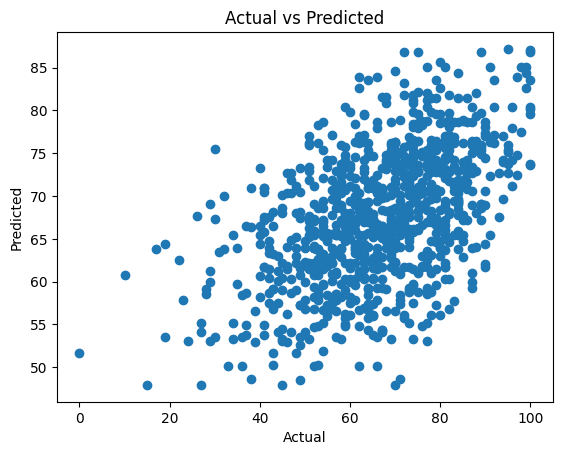

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_trial_test,model.predict(X_trial_test))
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Mean Squared Error:", mean_squared_error(y_trial_test, y_trial_pred))
print("R-squared:", r2_score(y_trial_test, y_trial_pred))
print("Mean Absolute Error:", mean_absolute_error(y_trial_test, y_trial_pred))
print("Root Mean Squared Error:", mean_squared_error(y_trial_test,y_trial_pred))
print("Group Root Mean Squared Error:", mean_squared_error(y_trial_test,y_trial_pred,multioutput='raw_values'))


Mean Squared Error: 186.20589611943603
R-squared: 0.2506813219780966
Mean Absolute Error: 10.847889394532798
Root Mean Squared Error: 186.20589611943603
Group Root Mean Squared Error: [195.7218623  187.75055817 175.14526789]


In [ ]:
import pandas as pd

# Create a DataFrame for bias detection, using 'math score' as an example target
df_bias_analysis_temp = X_trial_test.copy()
df_bias_analysis_temp['math_score_true'] = y_trial_test['math score']
df_bias_analysis_temp['math_score_pred'] = y_trial_pred[:, 0] # Assuming first column of y_trial_pred is math score predictions

# Save to a temporary CSV
temp_bias_csv_path = 'temp_bias_analysis_students_performance.csv'
df_bias_analysis_temp.to_csv(temp_bias_csv_path, index=False)

print(f"Temporary bias analysis CSV created at: {temp_bias_csv_path}")

Temporary bias analysis CSV created at: temp_bias_analysis_students_performance.csv


In [ ]:
import pandas as pd

# Create a comprehensive DataFrame for bias detection covering all 3 outputs
df_bias_full = X_trial_test.copy()

targets = ['math score', 'reading score', 'writing score']
for i, col in enumerate(targets):
    clean_name = col.replace(' ', '_')
    df_bias_full[f'{clean_name}_true'] = y_trial_test[col].values
    df_bias_full[f'{clean_name}_pred'] = y_trial_pred[:, i]

full_bias_csv = 'students_performance_multi_output_bias.csv'
df_bias_full.to_csv(full_bias_csv, index=False)
print(f"Prepared combined dataset for all targets: {full_bias_csv}")

Prepared combined dataset for all targets: students_performance_multi_output_bias.csv


In [ ]:
sen_features= [
    "gender_female",
    "gender_male",
    "race/ethnicity_group A",
    "race/ethnicity_group B",
    "race/ethnicity_group C",
    "race/ethnicity_group D",
    "race/ethnicity_group E"]
calculate_bias_for_feature(dataset_path=full_bias_csv,label_col='math_score_true',pred_col='math_score_pred',sensitive_feature_name=sen_features)

'{"status": "ok", "feature_tested": "[gender_female, gender_male, race/ethnicity_group A, race/ethnicity_group B, race/ethnicity_group C, race/ethnicity_group D, race/ethnicity_group E] (reconstructed)", "was_onehot_reconstructed": true, "groups_found": ["gender_female", "gender_male"], "binarization_applied": {"label_col": {"was_continuous": true, "strategy": "median", "cutoff_used": 65.0, "meaning": "scores >= 65.0 treated as positive (1)"}, "pred_col": {"was_continuous": true, "strategy": "median", "cutoff_used": 66.0751, "meaning": "predicted scores >= 66.0751 treated as positive (1)"}}, "demographic_parity_difference": 0.293, "disparate_impact_ratio": 0.549, "equalized_odds_difference": 0.3411, "per_metric_verdicts": {"demographic_parity": "FAIL", "disparate_impact": "FAIL", "equalized_odds": "FAIL"}, "overall_verdict": "BIASED", "plain_english": "Across groups in \'[gender_female, gender_male, race/ethnicity_group A, race/ethnicity_group B, race/ethnicity_group C, race/ethnicity_

In [ ]:
import os
from google.adk.runners import InMemoryRunner
from google.colab import userdata

key = userdata.get("GEMINI_API_KEY")
os.environ["GEMINI_API_KEY"] = key

# Auditing Math Score Bias
print("--- AUDITING BIAS FOR MATH SCORE ---")
root_agent_math = build_bias_pipeline(dataset_path=full_bias_csv, label_col='math_score_true', pred_col='math_score_pred')
runner_math = InMemoryRunner(agent=root_agent_math)
await runner_math.run_debug("Perform Bias Detection for math_score.")

# Auditing Reading Score Bias
# print("\n--- AUDITING BIAS FOR READING SCORE ---")
# root_agent_reading = build_bias_pipeline(dataset_path=full_bias_csv, label_col='reading_score_true', pred_col='reading_score_pred')
# runner_reading = InMemoryRunner(agent=root_agent_reading)
# await runner_reading.run_debug("Perform Bias Detection for reading_score.")

# # Auditing Writing Score Bias
# print("\n--- AUDITING BIAS FOR WRITING SCORE ---")
# root_agent_writing = build_bias_pipeline(dataset_path=full_bias_csv, label_col='writing_score_true', pred_col='writing_score_pred')
# runner_writing = InMemoryRunner(agent=root_agent_writing)
# await runner_writing.run_debug("Perform Bias Detection for writing_score.")

--- AUDITING BIAS FOR MATH SCORE ---

 ### Created new session: debug_session_id

User > Perform Bias Detection for math_score.
PredictorAgent > ```json
{
  "sensitive_candidates": [
    "gender_female",
    "gender_male",
    "race/ethnicity_group A",
    "race/ethnicity_group B",
    "race/ethnicity_group C",
    "race/ethnicity_group D",
    "race/ethnicity_group E",
    "parental level of education_associate's degree",
    "parental level of education_bachelor's degree",
    "parental level of education_high school",
    "parental level of education_master's degree",
    "parental level of education_some college",
    "parental level of education_some high school",
    "lunch_free/reduced",
    "lunch_standard",
    "test preparation course_completed",
    "test preparation course_none"
  ],
  "scoring_summary": {
    "gender_female": {
      "composite_score": 0.0967,
      "evidence": "Cramér's V=0.157 (association with outcome), NMI=0.066 (non-linear dependency), Outcome imbalan

[Event(model_version='gemini-2.5-flash', content=Content(
   parts=[
     Part(
       function_call=FunctionCall(
         args={
           'dataset_path': 'students_performance_multi_output_bias.csv',
           'label_col': 'math_score_true'
         },
         id='adk-8072c0ce-cac1-4142-905d-8b9a104b01dd',
         name='statistical_sensitivity_scorer'
       ),
       thought_signature=b'\n\xbb\x03\x01\x0c9\xd6\xc7D\xe4X\xef\xd8\x94\x8a\xe8\x90~\x99\xe7\xb8\x06\x15YC\xdd"x\x8e\xa5\xe4\x01\x1bQ\xcf\x0e\x91\xa2\xabm\xf0\xd3g$\xa3\xaf\xa8\x10AG8a\xeb\x1d\xf8\xed|\x7f\\\xa4-f\xf3t\x05fqHy\xa2\xfd\xf1\xd3[\xe6\xc1D\x94\xf7\xc2\xf3"Sn^n?E"(>\x9d\xdd\xc6|\xf9n...'
     ),
   ],
   role='model'
 ), grounding_metadata=None, partial=None, turn_complete=None, finish_reason=<FinishReason.STOP: 'STOP'>, error_code=None, error_message=None, interrupted=None, custom_metadata=None, usage_metadata=GenerateContentResponseUsageMetadata(
   candidates_token_count=40,
   prompt_token_count=712,
   p

Now that we have a temporary CSV with the true and predicted 'math score', we can configure the `label_col` and `pred_col` for the bias detection pipeline.

In [ ]:
file_path_for_bias_detection = temp_bias_csv_path
label_col_for_bias_detection = "math_score_true"
pred_col_for_bias_detection = "math_score_pred"

In [ ]:
import os
from google.adk.runners import InMemoryRunner

# Use the newly created variables for path, label, and prediction columns
root_agent=build_bias_pipeline(dataset_path=file_path_for_bias_detection, label_col=label_col_for_bias_detection, pred_col=pred_col_for_bias_detection)
runner = InMemoryRunner(agent=root_agent)

os.environ["GEMINI_API_KEY"] = key
await runner.run_debug(f"Perform Bias Detection on the provided dataset.")

In [ ]:
import os
from google.adk.runners import InMemoryRunner
label_col=
pred_col =
root_agent=build_bias_pipeline(dataset_path=path,label_col=label_col,pred_col=pred_col)
runner = InMemoryRunner(agent=root_agent)

os.environ["GEMINI_API_KEY"] = key
await runner.run_debug(f"Perform Bias Detection on the provided dataset.")

## Tool for Migration Predition

In [ ]:
# ═══════════════════════════════════════════════════════════
# tools_mitigation.py
# ═══════════════════════════════════════════════════════════

import io
import json
import pickle
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from fairlearn.preprocessing import CorrelationRemover
from fairlearn.reductions import ExponentiatedGradient, GridSearch
from fairlearn.reductions import DemographicParity, EqualizedOdds, ErrorRateParity
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
)

warnings.filterwarnings("ignore")

# ── Constants ──────────────────────────────────────────────
BIAS_THRESHOLDS = {
    "demographic_parity_difference": 0.10,
    "equalized_odds_difference":     0.10,
    "disparate_impact_ratio":        0.80,
}

CANDIDATE_MODELS = {
    "LogisticRegression":     LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree":           DecisionTreeClassifier(random_state=42),
    "RandomForest":           RandomForestClassifier(n_estimators=100, random_state=42),
    "GradientBoosting":       GradientBoostingClassifier(random_state=42),
}

OUTPUT_DIR = Path("./bias_pipeline_output")
OUTPUT_DIR.mkdir(exist_ok=True)


# ── Shared Helpers ─────────────────────────────────────────

def _load_and_prepare(dataset_path: str, label_col: str):
    """
    Loads CSV, encodes label to 0/1, one-hot encodes remaining
    categorical features, returns X, y, and the original df.
    """
    df = pd.read_csv(dataset_path)

    # Encode label → 0/1
    y_raw = df[label_col].copy()
    if not set(y_raw.unique()).issubset({0, 1}):
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y_raw), name=label_col)
    else:
        y = y_raw.astype(int)

    X = df.drop(columns=[label_col])

    # Drop any existing prediction column if present
    for col in ["y_pred", "model_predictions", "predicted"]:
        if col in X.columns:
            X = X.drop(columns=[col])

    # One-hot encode remaining categoricals for model training
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    if cat_cols:
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    X = X.fillna(X.median(numeric_only=True))

    return X, y, df


def _compute_bias_metrics(y_true, y_pred, sensitive_series) -> dict:
    """Returns the three core fairness metrics as a dict."""
    # Bin continuous sensitive features
    if pd.api.types.is_numeric_dtype(sensitive_series) and sensitive_series.nunique() > 10:
        try:
            sensitive_series = pd.qcut(
                sensitive_series, q=4, duplicates="drop"
            ).astype(str)
        except Exception:
            median = sensitive_series.median()
            sensitive_series = (sensitive_series > median).map(
                {True: "high", False: "low"}
            )

    dpd  = float(demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_series))
    dir_ = float(demographic_parity_ratio(y_true, y_pred,      sensitive_features=sensitive_series))
    eod  = float(equalized_odds_difference(y_true, y_pred,     sensitive_features=sensitive_series))
    return {
        "demographic_parity_difference": round(dpd,  4),
        "disparate_impact_ratio":        round(dir_, 4),
        "equalized_odds_difference":     round(eod,  4),
        "verdict": (
            "BIASED"
            if (abs(dpd) > BIAS_THRESHOLDS["demographic_parity_difference"]
                or dir_ < BIAS_THRESHOLDS["disparate_impact_ratio"]
                or abs(eod) > BIAS_THRESHOLDS["equalized_odds_difference"])
            else "FAIR"
        ),
    }


# ═══════════════════════════════════════════════════════════
# TOOL 1 — Select Mitigation Strategy
#           Used by StrategyAgent
# ═══════════════════════════════════════════════════════════

def select_mitigation_strategy(
    dataset_path: str,
    label_col: str,
    biased_columns: str,          # JSON list: '["col_a", "col_b"]'
    bias_scores_json: str,        # JSON dict of scores from ConfirmationAgent
) -> str:
    """
    Analyzes bias severity per column and assigns the most appropriate
    mitigation strategy using these rules:

    STRATEGY SELECTION LOGIC:
    ┌─────────────────────────────────────────────────────────┐
    │ DPD > 0.20  OR  DIR < 0.60                             │
    │   → REMOVE — column is severely biased, drop entirely   │
    │                                                         │
    │ DPD 0.10–0.20  AND  DIR 0.60–0.80                      │
    │   → CORRELATION_REMOVER — pre-process to decorrelate    │
    │     feature from sensitive attribute                     │
    │                                                         │
    │ DPD 0.10–0.15  AND  EOD > 0.10                         │
    │   → EQUALIZED_ODDS — in-processing with EqualizedOdds   │
    │     constraint (fixes both TPR and FPR gaps)            │
    │                                                         │
    │ DPD 0.10–0.15  AND  EOD ≤ 0.10                         │
    │   → DEMOGRAPHIC_PARITY — in-processing with DP          │
    │     constraint (fixes selection rate gap only)          │
    └─────────────────────────────────────────────────────────┘

    Args:
        dataset_path:      Path to CSV.
        label_col:         Target column name.
        biased_columns:    JSON string list of biased column names.
        bias_scores_json:  JSON dict mapping column → its bias metrics.

    Returns:
        JSON string with mitigation plan per column.
    """
    try:
        df          = pd.read_csv(dataset_path)
        biased_cols = json.loads(biased_columns)
        bias_scores = json.loads(bias_scores_json)

        mitigation_plan   = {}
        cols_to_remove    = []
        cols_to_preprocess = []
        cols_for_inprocess = []

        for col in biased_cols:
            if col not in df.columns:
                continue

            scores = bias_scores.get(col, {})
            dpd    = abs(scores.get("demographic_parity_difference", 0))
            dir_   = scores.get("disparate_impact_ratio", 1.0)
            eod    = abs(scores.get("equalized_odds_difference", 0))

            # Rule-based strategy assignment
            if dpd > 0.20 or dir_ < 0.60:
                strategy = "REMOVE"
                rationale = (
                    f"Severe bias — DPD={dpd:.3f} > 0.20 or DIR={dir_:.3f} < 0.60. "
                    "Column carries too much discriminatory signal to retain safely."
                )
                cols_to_remove.append(col)

            elif eod > 0.10:
                strategy = "EQUALIZED_ODDS"
                rationale = (
                    f"Moderate bias with TPR/FPR gap — EOD={eod:.3f} > 0.10. "
                    "ExponentiatedGradient with EqualizedOdds constraint will "
                    "equalize true and false positive rates across groups."
                )
                cols_for_inprocess.append(col)

            elif dpd > 0.15:
                strategy  = "CORRELATION_REMOVER"
                rationale = (
                    f"Moderate bias — DPD={dpd:.3f} in (0.15, 0.20]. "
                    "CorrelationRemover will decorrelate this feature from "
                    "the label while preserving predictive signal."
                )
                cols_to_preprocess.append(col)

            else:
                strategy  = "DEMOGRAPHIC_PARITY"
                rationale = (
                    f"Mild bias — DPD={dpd:.3f} in (0.10, 0.15]. "
                    "ExponentiatedGradient with DemographicParity constraint "
                    "will equalize selection rates across groups."
                )
                cols_for_inprocess.append(col)

            mitigation_plan[col] = {
                "strategy":  strategy,
                "rationale": rationale,
                "scores":    scores,
            }

        # Determine overall in-processing constraint
        # If ANY column needs EqualizedOdds → use EqualizedOdds (stricter)
        inprocess_constraint = (
            "EqualizedOdds" if any(
                mitigation_plan[c]["strategy"] == "EQUALIZED_ODDS"
                for c in cols_for_inprocess
            )
            else "DemographicParity"
        )

        return json.dumps({
            "status":                 "ok",
            "mitigation_plan":        mitigation_plan,
            "cols_to_remove":         cols_to_remove,
            "cols_to_preprocess":     cols_to_preprocess,
            "cols_for_inprocessing":  cols_for_inprocess,
            "inprocess_constraint":   inprocess_constraint,
            "summary": (
                f"{len(cols_to_remove)} column(s) will be REMOVED, "
                f"{len(cols_to_preprocess)} will use CorrelationRemover, "
                f"{len(cols_for_inprocess)} will use {inprocess_constraint} constraint."
            ),
        })

    except Exception as e:
        return json.dumps({"status": "error", "message": str(e)})


# ═══════════════════════════════════════════════════════════
# TOOL 2 — Apply Mitigation and Train Models
#           Used by RetrainingAgent
# ═══════════════════════════════════════════════════════════

def apply_mitigation_and_train(
    dataset_path: str,
    label_col: str,
    mitigation_plan_json: str,     # Full JSON from Tool 1
    primary_sensitive_col: str,    # Single most important sensitive col
) -> str:
    """
    Applies the mitigation plan and trains multiple candidate models.

    Steps:
      1. Remove columns flagged as REMOVE
      2. Apply CorrelationRemover to CORRELATION_REMOVER columns
      3. Train each candidate model with fairness constraint via
         ExponentiatedGradient
      4. Score each model on accuracy + fairness composite
      5. Return all results — best model path saved to disk

    Args:
        dataset_path:          Path to CSV.
        label_col:             Target column.
        mitigation_plan_json:  JSON output from select_mitigation_strategy.
        primary_sensitive_col: The most biased sensitive column (used as
                               the fairness constraint anchor).

    Returns:
        JSON with all model results, best model name, and saved .pkl path.
    """
    try:
        plan        = json.loads(mitigation_plan_json)
        remove_cols = plan.get("cols_to_remove", [])
        pre_cols    = plan.get("cols_to_preprocess", [])
        constraint  = plan.get("inprocess_constraint", "DemographicParity")

        X, y, df_raw = _load_and_prepare(dataset_path, label_col)

        # ── Step 1: Remove severely biased columns ──────────────
        encoded_remove = []
        for col in remove_cols:
            # After get_dummies, original col may be split into col_val1, col_val2...
            matched = [c for c in X.columns if c == col or c.startswith(f"{col}_")]
            encoded_remove.extend(matched)

        if encoded_remove:
            X = X.drop(columns=encoded_remove, errors="ignore")

        # ── Step 2: CorrelationRemover on pre-process cols ───────
        pre_encoded = []
        for col in pre_cols:
            matched = [c for c in X.columns if c == col or c.startswith(f"{col}_")]
            pre_encoded.extend(matched)

        if pre_encoded:
            cr = CorrelationRemover(sensitive_feature_ids=pre_encoded)
            X_arr     = cr.fit_transform(X)
            remaining = [c for c in X.columns if c not in pre_encoded]
            X         = pd.DataFrame(X_arr, columns=remaining, index=X.index)

        # ── Step 3: Prepare sensitive feature for constraint ─────
        sensitive_series = df_raw[primary_sensitive_col].reset_index(drop=True)
        if pd.api.types.is_numeric_dtype(sensitive_series) and sensitive_series.nunique() > 10:
            try:
                sensitive_series = pd.qcut(
                    sensitive_series, q=4, duplicates="drop"
                ).astype(str)
            except Exception:
                median = sensitive_series.median()
                sensitive_series = (sensitive_series > median).map(
                    {True: "high", False: "low"}
                )

        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)
        sensitive_series = sensitive_series.reset_index(drop=True)

        # ── Step 4: Train/test split ─────────────────────────────
        X_tr, X_te, y_tr, y_te, sf_tr, sf_te = train_test_split(
            X, y, sensitive_series,
            test_size=0.25, random_state=42, stratify=y,
        )

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        # ── Step 5: Fairness constraint object ───────────────────
        fairness_constraint = (
            EqualizedOdds() if constraint == "EqualizedOdds"
            else DemographicParity()
        )

        # ── Step 6: Train all candidates ─────────────────────────
        model_results = {}
        best_model    = None
        best_score    = -1
        best_name     = ""

        for model_name, base_model in CANDIDATE_MODELS.items():
            try:
                # Wrap with ExponentiatedGradient for fairness
                fair_model = ExponentiatedGradient(
                    estimator=base_model,
                    constraints=fairness_constraint,
                    max_iter=50,
                )
                fair_model.fit(X_tr_s, y_tr, sensitive_features=sf_tr)
                y_pred = fair_model.predict(X_te_s)

                # Accuracy metrics
                acc = round(accuracy_score(y_te, y_pred), 4)
                f1  = round(f1_score(y_te, y_pred, zero_division=0), 4)

                # Fairness metrics post-mitigation
                bias = _compute_bias_metrics(y_te, y_pred, sf_te.reset_index(drop=True))

                # Composite score: 60% accuracy + 40% fairness
                # Fairness score = 1 - normalized avg of violations
                dpd_viol = max(0, abs(bias["demographic_parity_difference"]) - 0.10)
                dir_viol = max(0, 0.80 - bias["disparate_impact_ratio"])
                eod_viol = max(0, abs(bias["equalized_odds_difference"]) - 0.10)
                fairness_score = max(0, 1 - (dpd_viol + dir_viol + eod_viol))

                composite = round(0.60 * acc + 0.40 * fairness_score, 4)

                model_results[model_name] = {
                    "accuracy":    acc,
                    "f1_score":    f1,
                    "bias_after":  bias,
                    "fairness_score":  round(fairness_score, 4),
                    "composite_score": composite,
                }

                if composite > best_score:
                    best_score = composite
                    best_model = fair_model
                    best_name  = model_name

            except Exception as model_err:
                model_results[model_name] = {
                    "status": "failed",
                    "error":  str(model_err),
                }

        # ── Step 7: Save best model + scaler (temp path) ─────────
        temp_path = OUTPUT_DIR / f"best_model_candidate_{best_name}.pkl"
        with open(temp_path, "wb") as f:
            pickle.dump({
                "model":           best_model,
                "scaler":          scaler,
                "feature_columns": list(X.columns),
                "label_col":       label_col,
                "removed_cols":    remove_cols,
                "constraint_used": constraint,
            }, f)

        return json.dumps({
            "status":           "ok",
            "models_trained":   list(model_results.keys()),
            "model_results":    model_results,
            "best_model_name":  best_name,
            "best_composite_score": best_score,
            "temp_pkl_path":    str(temp_path),
            "columns_removed":  remove_cols,
            "constraint_used":  constraint,
            "note": (
                f"Best model: {best_name} with composite score {best_score:.4f} "
                f"(60% accuracy + 40% fairness). Run validate_and_export_pkl next."
            ),
        })

    except Exception as e:
        return json.dumps({"status": "error", "message": str(e)})


# ═══════════════════════════════════════════════════════════
# TOOL 3 — Validate Fair Model & Export Final .pkl
#           Used by RetrainingAgent
# ═══════════════════════════════════════════════════════════

def validate_and_export_pkl(
    temp_pkl_path: str,
    dataset_path: str,
    label_col: str,
    primary_sensitive_col: str,
    original_bias_scores_json: str,  # scores BEFORE mitigation
    output_filename: str = "fair_model.pkl",
) -> str:
    """
    Validates the best model by comparing bias BEFORE vs AFTER mitigation,
    then exports the final production-ready .pkl.

    The .pkl contains:
      {
        "model":             <trained fair model>,
        "scaler":            <fitted StandardScaler>,
        "feature_columns":   <list of expected input columns>,
        "label_col":         <target column name>,
        "removed_cols":      <columns to drop before inference>,
        "constraint_used":   <fairness constraint applied>,
        "bias_validation":   <before/after comparison>,
        "model_metadata":    <training info>
      }

    Args:
        temp_pkl_path:             Path to temp .pkl from apply_mitigation_and_train.
        dataset_path:              Original CSV path.
        label_col:                 Target column.
        primary_sensitive_col:     Most important sensitive column.
        original_bias_scores_json: Bias scores before mitigation (for comparison).
        output_filename:           Final .pkl filename.

    Returns:
        JSON with full before/after comparison and final .pkl path.
    """
    try:
        # Load temp model bundle
        with open(temp_pkl_path, "rb") as f:
            bundle = pickle.load(f)

        model          = bundle["model"]
        scaler         = bundle["scaler"]
        feature_cols   = bundle["feature_columns"]
        removed_cols   = bundle["removed_cols"]
        constraint     = bundle["constraint_used"]
        original_scores = json.loads(original_bias_scores_json)

        # Reload and prepare data
        X, y, df_raw = _load_and_prepare(dataset_path, label_col)

        # Apply same column removal
        drop_encoded = []
        for col in removed_cols:
            matched = [c for c in X.columns if c == col or c.startswith(f"{col}_")]
            drop_encoded.extend(matched)
        X = X.drop(columns=drop_encoded, errors="ignore")

        # Align columns to what model expects
        for col in feature_cols:
            if col not in X.columns:
                X[col] = 0
        X = X[feature_cols]

        X_scaled = scaler.transform(X)

        # Sensitive feature
        sensitive_series = df_raw[primary_sensitive_col].reset_index(drop=True)
        if pd.api.types.is_numeric_dtype(sensitive_series) and sensitive_series.nunique() > 10:
            try:
                sensitive_series = pd.qcut(
                    sensitive_series, q=4, duplicates="drop"
                ).astype(str)
            except Exception:
                median = sensitive_series.median()
                sensitive_series = (sensitive_series > median).map(
                    {True: "high", False: "low"}
                )

        y_pred_fair = model.predict(X_scaled)

        # Bias AFTER mitigation
        bias_after = _compute_bias_metrics(
            y.reset_index(drop=True),
            pd.Series(y_pred_fair),
            sensitive_series,
        )

        # Bias BEFORE (from original report)
        orig = original_scores.get(primary_sensitive_col, {})
        bias_before = {
            "demographic_parity_difference": orig.get("demographic_parity_difference", "N/A"),
            "disparate_impact_ratio":        orig.get("disparate_impact_ratio", "N/A"),
            "equalized_odds_difference":     orig.get("equalized_odds_difference", "N/A"),
        }

        # Compute improvements
        def _improvement(before, after):
            if before == "N/A":
                return "N/A"
            return round(float(before) - float(after), 4)

        comparison = {
            "demographic_parity_difference": {
                "before":      bias_before["demographic_parity_difference"],
                "after":       bias_after["demographic_parity_difference"],
                "improvement": _improvement(
                    bias_before["demographic_parity_difference"],
                    abs(bias_after["demographic_parity_difference"])
                ),
            },
            "disparate_impact_ratio": {
                "before":      bias_before["disparate_impact_ratio"],
                "after":       bias_after["disparate_impact_ratio"],
                "improvement": _improvement(
                    bias_after["disparate_impact_ratio"],
                    float(bias_before["disparate_impact_ratio"])
                    if bias_before["disparate_impact_ratio"] != "N/A" else 0
                ),
            },
            "equalized_odds_difference": {
                "before":      bias_before["equalized_odds_difference"],
                "after":       bias_after["equalized_odds_difference"],
                "improvement": _improvement(
                    bias_before["equalized_odds_difference"],
                    abs(bias_after["equalized_odds_difference"])
                ),
            },
        }

        validation_passed = bias_after["verdict"] == "FAIR"

        # Build final bundle with metadata
        final_bundle = {
            **bundle,
            "bias_validation": {
                "before":            bias_before,
                "after":             bias_after,
                "comparison":        comparison,
                "validation_passed": validation_passed,
            },
            "model_metadata": {
                "trained_on":       dataset_path,
                "label_col":        label_col,
                "sensitive_col":    primary_sensitive_col,
                "constraint_used":  constraint,
                "fairlearn_version": "0.10.x",
            },
        }

        # Export final .pkl
        final_path = OUTPUT_DIR / output_filename
        with open(final_path, "wb") as f:
            pickle.dump(final_bundle, f)

        return json.dumps({
            "status":             "ok",
            "validation_passed":  validation_passed,
            "bias_before":        bias_before,
            "bias_after":         bias_after,
            "improvement":        comparison,
            "final_pkl_path":     str(final_path),
            "verdict": (
                "✅ Model passed fairness validation. Safe to deploy."
                if validation_passed
                else "⚠️ Model reduced bias but still fails some thresholds. "
                     "Consider stricter constraints or removing more columns."
            ),
        })

    except Exception as e:
        return json.dumps({"status": "error", "message": str(e)})

In [ ]:
# ═══════════════════════════════════════════════════════════
# agents.py — Complete pipeline (all 4 agents)
# ═══════════════════════════════════════════════════════════

from google.adk import Agent
from google.adk.agents.sequential_agent import SequentialAgent

# from tools import (
#     statistical_sensitivity_scorer,
#     keyword_heuristic_scanner,
#     calculate_bias_for_feature,
# )
# from tools_mitigation import (
#     select_mitigation_strategy,
#     apply_mitigation_and_train,
#     validate_and_export_pkl,
# )


def build_full_pipeline(
    dataset_path: str,
    label_col: str,
    pred_col: str,
    output_filename: str = "fair_model.pkl",
) -> SequentialAgent:

    if label_col == pred_col:
        raise ValueError("label_col and pred_col must be different columns.")

    # ── Agent 1: PredictorAgent ────────────────────────────
    predictor_agent = Agent(
        name="PredictorAgent",
        model="gemini-2.0-flash",
        description="Statistically identifies sensitive proxy columns.",
        instruction=f"""
You are an AI Fairness Analyst identifying sensitive proxy columns
using ONLY mathematical evidence — no guessing.

Steps:
  1. Call statistical_sensitivity_scorer:
       dataset_path = "{dataset_path}"
       label_col    = "{label_col}"
  2. Call keyword_heuristic_scanner with the same arguments.
  3. Merge: flag a column if it appears in EITHER tool's output.
  4. Output ONLY this JSON to session state (key: sensitive_candidates):
     {{
       "sensitive_candidates": ["col_a", "col_b"],
       "scoring_summary": {{"col_a": {{"composite_score": 0.45, ...}}}}
     }}
""",
        tools=[statistical_sensitivity_scorer, keyword_heuristic_scanner],
        output_key="sensitive_candidates",
    )

    # ── Agent 2: ConfirmationAgent ─────────────────────────
    confirmation_agent = Agent(
        name="ConfirmationAgent",
        model="gemini-2.0-flash",
        description="Confirms bias with Fairlearn and writes bias report.",
        instruction=f"""
You are an AI Compliance Officer confirming bias mathematically.

Read sensitive_candidates from session: {{sensitive_candidates}}

Steps:
  1. For EACH candidate, call calculate_bias_for_feature:
       dataset_path           = "{dataset_path}"
       label_col              = "{label_col}"
       pred_col               = "{pred_col}"
       sensitive_feature_name = <column>
  2. Collect all results.
  3. Store results to session state key "bias_report" as:
     {{
       "biased_columns": ["col_a"],
       "cleared_columns": ["col_b"],
       "scores": {{
         "col_a": {{
           "demographic_parity_difference": 0.21,
           "disparate_impact_ratio": 0.55,
           "equalized_odds_difference": 0.12,
           "overall_verdict": "BIASED"
         }}
       }}
     }}
  4. Also print a human-readable Executive Bias Report.
""",
        tools=[calculate_bias_for_feature],
        output_key="bias_report",
    )

    # ── Agent 3: StrategyAgent ─────────────────────────────
    strategy_agent = Agent(
        name="StrategyAgent",
        model="gemini-2.0-flash",
        description="Assigns the best mitigation strategy per biased column.",
        instruction=f"""
You are an AI Fairness Strategist. Read the bias report from session:
{{bias_report}}

Steps:
  1. Extract the "biased_columns" list and "scores" dict from bias_report.
  2. Call select_mitigation_strategy with:
       dataset_path       = "{dataset_path}"
       label_col          = "{label_col}"
       biased_columns     = <JSON string of biased_columns list>
       bias_scores_json   = <JSON string of scores dict>
  3. Store the full tool output to session key "mitigation_plan".
  4. Also identify the SINGLE most biased column (highest DPD) and
     store its name to session key "primary_sensitive_col".
  5. Print a clear summary of which strategy each column will receive
     and WHY (use the rationale from the tool output).
""",
        tools=[select_mitigation_strategy],
        output_key="mitigation_plan",
    )

    # ── Agent 4: RetrainingAgent ───────────────────────────
    retraining_agent = Agent(
        name="RetrainingAgent",
        model="gemini-2.0-flash",
        description="Applies mitigation, trains fair models, exports .pkl.",
        instruction=f"""
You are an AI Model Engineer. Your job is to apply the mitigation plan,
train fair models, validate, and export the final .pkl.

Read from session:
  - mitigation_plan       → {{mitigation_plan}}
  - primary_sensitive_col → {{primary_sensitive_col}}
  - bias_report           → {{bias_report}}

Steps:
  1. Call apply_mitigation_and_train:
       dataset_path          = "{dataset_path}"
       label_col             = "{label_col}"
       mitigation_plan_json  = <full JSON string of mitigation_plan>
       primary_sensitive_col = <value from primary_sensitive_col session key>

  2. From the result, extract "temp_pkl_path" and "best_model_name".
     Print a comparison table of all models trained showing their
     accuracy, fairness score, and composite score.

  3. Call validate_and_export_pkl:
       temp_pkl_path              = <temp_pkl_path from step 2>
       dataset_path               = "{dataset_path}"
       label_col                  = "{label_col}"
       primary_sensitive_col      = <primary_sensitive_col>
       original_bias_scores_json  = <scores dict from bias_report as JSON>
       output_filename            = "{output_filename}"

  4. Print the final Mitigation Report:

  ═══════════════════════════════════════
        MITIGATION REPORT
  ═══════════════════════════════════════
  Best Model      : <model name>
  Constraint Used : <DemographicParity / EqualizedOdds>
  Columns Removed : <list>

  BEFORE vs AFTER (on <primary_sensitive_col>)
  ┌──────────────────────────┬────────┬────────┬────────────┐
  │ Metric                   │ Before │ After  │ Improvement│
  ├──────────────────────────┼────────┼────────┼────────────┤
  │ DPD (lower is better)    │        │        │            │
  │ DIR (higher is better)   │        │        │            │
  │ EOD (lower is better)    │        │        │            │
  └──────────────────────────┴────────┴────────┴────────────┘

  Validation  : PASSED ✅ / FAILED ⚠️
  Output .pkl : <final_pkl_path>
  ═══════════════════════════════════════
""",
        tools=[apply_mitigation_and_train, validate_and_export_pkl],
    )

    # ── Full Pipeline ──────────────────────────────────────
    return SequentialAgent(
        name="FullBiasPipeline",
        description=(
            "End-to-end: detect sensitive columns → confirm bias → "
            "plan mitigation → retrain fair model → export .pkl"
        ),
        sub_agents=[
            predictor_agent,
            confirmation_agent,
            strategy_agent,
            retraining_agent,
        ],
    )